In [1]:
import torch
import argparse
import torch.nn as nn
import torch.optim as optim
import time

from tqdm.auto import tqdm

from google.colab import drive
drive.mount('/content/drive')

import sys
sys.path.append('/content/drive/MyDrive/ResNetModel/src')
from model import build_model
from findmydatasets import get_datasets, get_data_loaders
from utils import save_model, save_plots

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
seed = 45
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = True

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# Construct the argument parser.
parser = argparse.ArgumentParser()
parser.add_argument(
    '-e', '--epochs', type=int, default=35,
    help='Number of epochs to train our network for'
)
parser.add_argument(
    '-lr', '--learning-rate', type=float,
    dest='learning_rate', default=0.001,
    help='Learning rate for training the model'
)
args = vars(parser.parse_args([]))

In [5]:
# Training function.
def train(model, trainloader, optimizer, criterion):
    model.train()
    print('Training')
    train_running_loss = 0.0
    train_running_correct = 0
    counter = 0
    for i, data in tqdm(enumerate(trainloader), total=len(trainloader)):
        counter += 1
        image, labels = data
        image = image.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        # Forward pass.
        outputs = model(image)
        # Calculate the loss.
        loss = criterion(outputs, labels)
        train_running_loss += loss.item()
        # Calculate the accuracy.
        _, preds = torch.max(outputs.data, 1)
        train_running_correct += (preds == labels).sum().item()
        # Backpropagation.
        loss.backward()
        # Update the weights.
        optimizer.step()

    # Loss and accuracy for the complete epoch.
    epoch_loss = train_running_loss / counter
    epoch_acc = 100. * (train_running_correct / len(trainloader.dataset))
    return epoch_loss, epoch_acc

In [6]:
# Validation function.
def validate(model, testloader, criterion, class_names):
    model.eval()
    print('Validation')
    valid_running_loss = 0.0
    valid_running_correct = 0
    counter = 0

    with torch.no_grad():
        for i, data in tqdm(enumerate(testloader), total=len(testloader)):
            counter += 1

            image, labels = data
            image = image.to(device)
            labels = labels.to(device)
            # Forward pass.
            outputs = model(image)
            # Calculate the loss.
            loss = criterion(outputs, labels)
            valid_running_loss += loss.item()
            # Calculate the accuracy.
            _, preds = torch.max(outputs.data, 1)
            valid_running_correct += (preds == labels).sum().item()

    # Loss and accuracy for the complete epoch.
    epoch_loss = valid_running_loss / counter
    epoch_acc = 100. * (valid_running_correct / len(testloader.dataset))
    return epoch_loss, epoch_acc

[INFO]: Number of training images: 132
[INFO]: Number of validation images: 41
[INFO]: Classes: ['OccludedEye', 'OpenEye']
Computation device: cpu
Learning rate: 0.001
Epochs to train for: 35

[INFO]: Loading pre-trained weights


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


[INFO]: Fine-tuning all layers...
11,177,538 total parameters.
11,177,538 training parameters.
[INFO]: Epoch 1 of 35
Training


  0%|          | 0/5 [00:00<?, ?it/s]

Validation


...

Training loss: 0.010, training acc: 100.000
Validation loss: 0.241, validation acc: 97.561
--------------------------------------------------
[INFO]: Epoch 35 of 35
Training


  0%|          | 0/5 [00:00<?, ?it/s]

Validation


  0%|          | 0/2 [00:00<?, ?it/s]

Training loss: 0.038, training acc: 97.727
Validation loss: 0.323, validation acc: 92.683
--------------------------------------------------
TRAINING COMPLETE


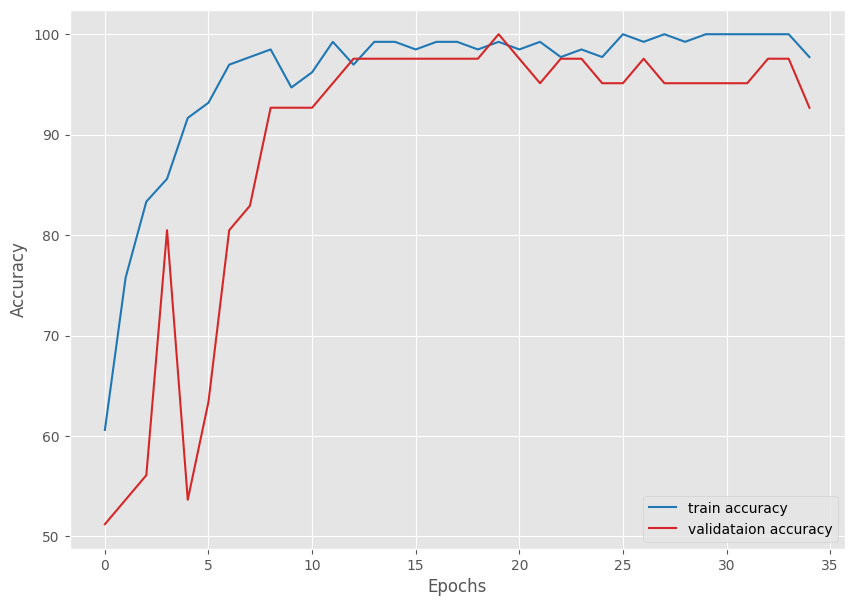

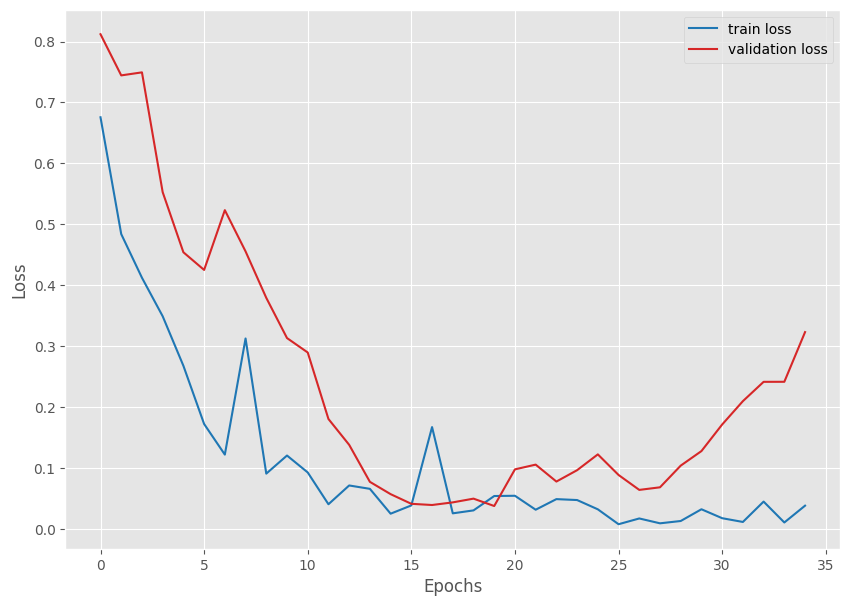

In [7]:
if __name__ == '__main__':
    # Load the training and validation datasets.
    dataset_train, dataset_valid, dataset_classes = get_datasets()
    print(f"[INFO]: Number of training images: {len(dataset_train)}")
    print(f"[INFO]: Number of validation images: {len(dataset_valid)}")
    print(f"[INFO]: Classes: {dataset_classes}")
    # Load the training and validation data loaders.
    train_loader, valid_loader = get_data_loaders(dataset_train, dataset_valid)

    # Learning_parameters.
    lr = args['learning_rate']
    epochs = args['epochs']
    device = ('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Computation device: {device}")
    print(f"Learning rate: {lr}")
    print(f"Epochs to train for: {epochs}\n")

    # Load the model.
    model = build_model(
        pretrained=True,
        fine_tune=True,
        num_classes=len(dataset_classes)
    ).to(device)

    # Total parameters and trainable parameters.
    total_params = sum(p.numel() for p in model.parameters())
    print(f"{total_params:,} total parameters.")
    total_trainable_params = sum(
        p.numel() for p in model.parameters() if p.requires_grad)
    print(f"{total_trainable_params:,} training parameters.")

    # Optimizer.
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    # Loss function.
    criterion = nn.CrossEntropyLoss()

    # Lists to keep track of losses and accuracies.
    train_loss, valid_loss = [], []
    train_acc, valid_acc = [], []
    # Start the training.
    for epoch in range(epochs):
        print(f"[INFO]: Epoch {epoch+1} of {epochs}")
        train_epoch_loss, train_epoch_acc = train(model, train_loader,
                                                optimizer, criterion)
        valid_epoch_loss, valid_epoch_acc = validate(model, valid_loader,
                                                    criterion, dataset_classes)
        train_loss.append(train_epoch_loss)
        valid_loss.append(valid_epoch_loss)
        train_acc.append(train_epoch_acc)
        valid_acc.append(valid_epoch_acc)
        print(f"Training loss: {train_epoch_loss:.3f}, training acc: {train_epoch_acc:.3f}")
        print(f"Validation loss: {valid_epoch_loss:.3f}, validation acc: {valid_epoch_acc:.3f}")
        print('-'*50)
        time.sleep(2)

    # Save the trained model weights.
    save_model(epochs, model, optimizer, criterion)
    # Save the loss and accuracy plots.
    save_plots(train_acc, valid_acc, train_loss, valid_loss)
    print('TRAINING COMPLETE')